Imports and setup

In [1]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
)

from sklearn.preprocessing import label_binarize


PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from src.data.dataset import WasteDataset
from src.data.transforms import get_eval_transforms
from src.models.resnet50 import create_resnet50
from src.evaluation.metrics import (
    collect_predictions,
    calculate_classification_metrics,
)
from src.utils.seed import set_seed


set_seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


Create the test dataset

In [2]:
from torch.utils.data import DataLoader


test_dataset = WasteDataset(
    manifest_path=PROJECT_ROOT / "data/manifests/test.csv",
    dataset_root=PROJECT_ROOT / "data/raw/garbage-dataset",
    transform=get_eval_transforms(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)


print("Test images:", len(test_dataset))
print("Classes:", test_dataset.class_to_idx)

Test images: 2965
Classes: {'battery': 0, 'biological': 1, 'cardboard': 2, 'clothes': 3, 'glass': 4, 'metal': 5, 'paper': 6, 'plastic': 7, 'shoes': 8, 'trash': 9}


Load the selected ResNet50 checkpoint

In [3]:
model = create_resnet50(
    num_classes=10,
    pretrained=True,
    freeze_backbone=True,
)

In [4]:
checkpoint_path = (
    PROJECT_ROOT
    / "results"
    / "checkpoints"
    / "resnet50_layer4_finetuned_best.pth"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("Loaded checkpoint:", checkpoint_path.name)
print("Selected epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["val_loss"])
print("Validation accuracy:", checkpoint["val_accuracy"])

Loaded checkpoint: resnet50_layer4_finetuned_best.pth
Selected epoch: 3
Validation loss: 0.12801878098096803
Validation accuracy: 0.9659244264507423


Verify model output once

In [5]:
images, labels = next(iter(test_loader))

images = images.to(device)

with torch.inference_mode():
    outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 10])


Final test predictions

In [6]:
y_true, y_pred, y_prob = collect_predictions(
    model=model,
    dataloader=test_loader,
    device=device,
)

print("True labels:", y_true.shape)
print("Predictions:", y_pred.shape)
print("Probabilities:", y_prob.shape)

True labels: (2965,)
Predictions: (2965,)
Probabilities: (2965, 10)


Calculate final test metrics

In [7]:
class_to_idx = test_dataset.class_to_idx

class_names = [
    class_name
    for class_name, index in sorted(
        class_to_idx.items(),
        key=lambda item: item[1],
    )
]

print(class_names)

['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


In [8]:
metrics, report, matrix = (
    calculate_classification_metrics(
        y_true=y_true,
        y_pred=y_pred,
        class_names=class_names,
    )
)

print("FINAL RESNET50 TEST RESULTS")
print("-" * 35)

for metric_name, value in metrics.items():
    print(
        f"{metric_name:20s}: "
        f"{value:.4f}"
    )

FINAL RESNET50 TEST RESULTS
-----------------------------------
accuracy            : 0.9524
macro_precision     : 0.9436
macro_recall        : 0.9436
macro_f1            : 0.9434
weighted_f1         : 0.9523


Per-class test results

In [9]:
report_df = pd.DataFrame(
    report
).transpose()

display(
    report_df[
        [
            "precision",
            "recall",
            "f1-score",
            "support",
        ]
    ]
)

,precision,recall,f1-score,support
battery,0.971831,0.978723,0.975265,141.000000
biological,0.972789,0.959732,0.966216,149.000000
cardboard,0.960573,0.978102,0.969259,274.000000
clothes,0.989861,0.977472,0.983627,799.000000
glass,0.946352,0.958696,0.952484,460.000000
metal,0.910256,0.928105,0.919094,153.000000
paper,0.937238,0.888889,0.912424,252.000000
plastic,0.918089,0.902685,0.910321,298.000000
shoes,0.930380,0.989899,0.959217,297.000000
trash,0.898551,0.873239,0.885714,142.000000


Final confusion matrix

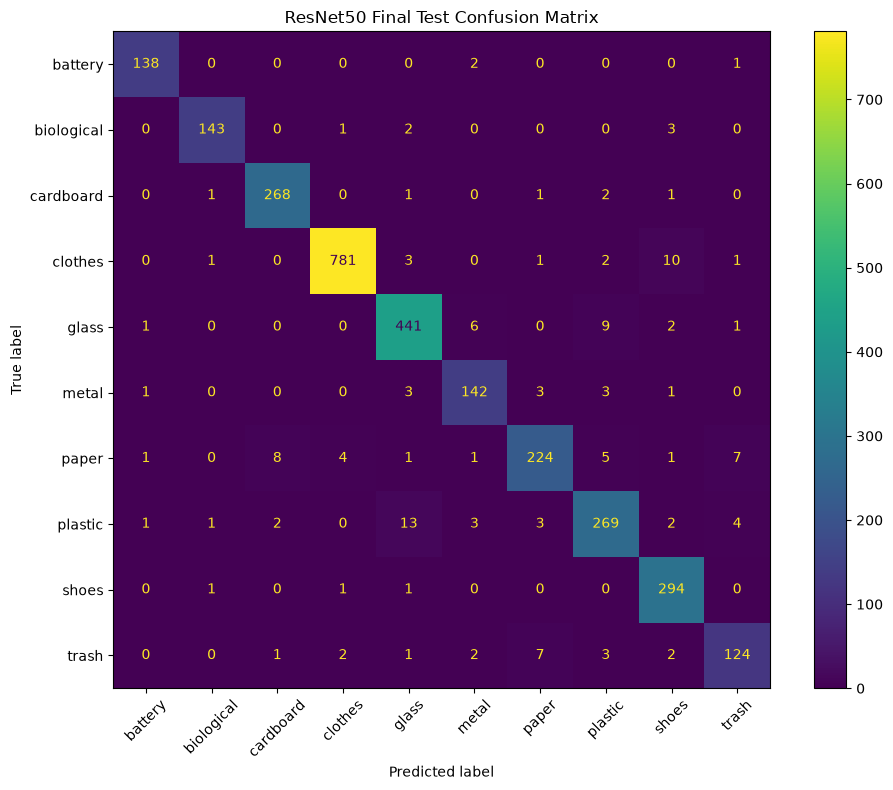

In [10]:
fig, ax = plt.subplots(
    figsize=(10, 8)
)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=class_names,
)

cm_display.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d",
)

plt.title(
    "ResNet50 Final Test Confusion Matrix"
)

plt.tight_layout()
plt.show()

Final ROC-AUC

In [11]:
y_true_binary = label_binarize(
    y_true,
    classes=range(len(class_names)),
)

macro_roc_auc = roc_auc_score(
    y_true_binary,
    y_prob,
    average="macro",
    multi_class="ovr",
)

weighted_roc_auc = roc_auc_score(
    y_true_binary,
    y_prob,
    average="weighted",
    multi_class="ovr",
)

print(
    f"Macro ROC-AUC: "
    f"{macro_roc_auc:.4f}"
)

print(
    f"Weighted ROC-AUC: "
    f"{weighted_roc_auc:.4f}"
)

Macro ROC-AUC: 0.9977
Weighted ROC-AUC: 0.9981


Generate ROC curves

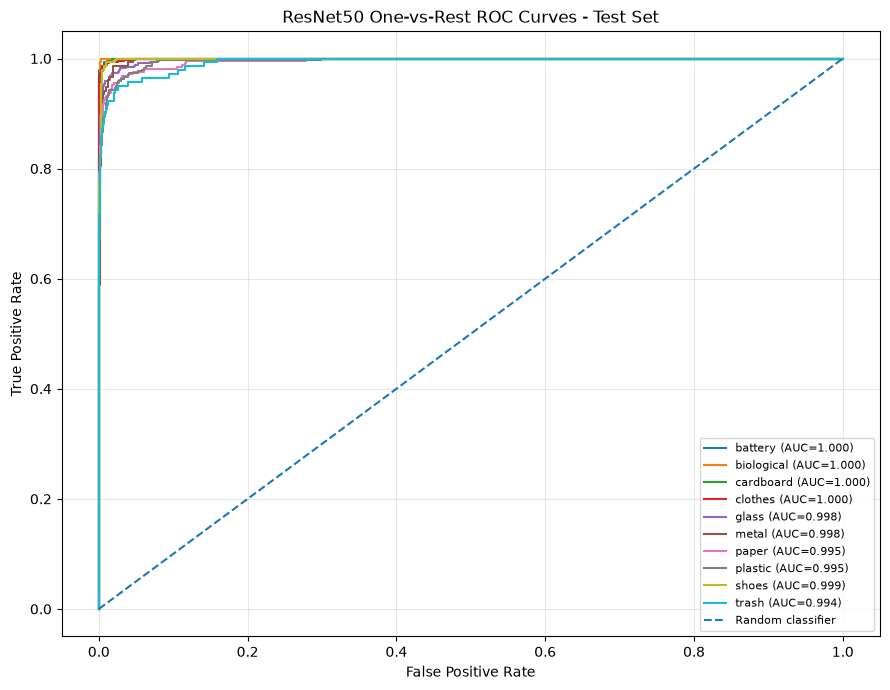

In [12]:
plt.figure(figsize=(9, 7))

for class_index, class_name in enumerate(
    class_names
):

    fpr, tpr, _ = roc_curve(
        y_true_binary[:, class_index],
        y_prob[:, class_index],
    )

    class_auc = auc(
        fpr,
        tpr,
    )

    plt.plot(
        fpr,
        tpr,
        label=(
            f"{class_name} "
            f"(AUC={class_auc:.3f})"
        ),
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ResNet50 One-vs-Rest ROC Curves - Test Set"
)

plt.legend(
    loc="lower right",
    fontsize=8,
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Model complexity

In [13]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(
    f"Total parameters: "
    f"{total_params:,}"
)

print(
    f"Total parameters (M): "
    f"{total_params / 1_000_000:.2f}M"
)

Total parameters: 23,528,522
Total parameters (M): 23.53M


Check checkpoint size

In [14]:
checkpoint_size_mb = (
    checkpoint_path.stat().st_size
    / (1024 ** 2)
)

print(
    f"Checkpoint size: "
    f"{checkpoint_size_mb:.2f} MB"
)

Checkpoint size: 204.42 MB


Measure inference speed

In [15]:
model.eval()

warmup_images, _ = next(iter(test_loader))

warmup_images = warmup_images.to(device)

with torch.inference_mode():

    for _ in range(5):
        _ = model(warmup_images)

if torch.cuda.is_available():
    torch.cuda.synchronize()

In [16]:
start_time = time.perf_counter()

total_images = 0

with torch.inference_mode():

    for images, _ in test_loader:

        images = images.to(
            device,
            non_blocking=True,
        )

        _ = model(images)

        total_images += images.size(0)


if torch.cuda.is_available():
    torch.cuda.synchronize()


elapsed_time = (
    time.perf_counter()
    - start_time
)

ms_per_image = (
    elapsed_time
    / total_images
    * 1000
)

images_per_second = (
    total_images
    / elapsed_time
)


print(
    f"Images evaluated: "
    f"{total_images}"
)

print(
    f"Total inference time: "
    f"{elapsed_time:.2f}s"
)

print(
    f"Average inference: "
    f"{ms_per_image:.2f} ms/image"
)

print(
    f"Throughput: "
    f"{images_per_second:.2f} images/s"
)

Images evaluated: 2965
Total inference time: 13.27s
Average inference: 4.47 ms/image
Throughput: 223.48 images/s


Save final test results

In [17]:
results_dir = (
    PROJECT_ROOT
    / "results"
    / "tables"
)

results_dir.mkdir(
    parents=True,
    exist_ok=True,
)

In [18]:
report_path = (
    results_dir
    / "resnet50_final_test_classification_report.csv"
)

report_df.to_csv(
    report_path
)

print(
    "Saved:",
    report_path,
)

Saved: c:\Users\USER\Desktop\SLIIT\DL\Assignment\waste-classification\results\tables\resnet50_final_test_classification_report.csv


Create the overall summary

In [19]:
final_results = {
    "model": "ResNet50",
    "configuration": "ImageNet pretrained + layer4 fine-tuning",
    "accuracy": metrics["accuracy"],
    "macro_precision": metrics["macro_precision"],
    "macro_recall": metrics["macro_recall"],
    "macro_f1": metrics["macro_f1"],
    "weighted_f1": metrics["weighted_f1"],
    "macro_roc_auc": macro_roc_auc,
    "weighted_roc_auc": weighted_roc_auc,
    "parameters": total_params,
    "parameters_millions": total_params / 1_000_000,
    "checkpoint_size_mb": checkpoint_size_mb,
    "inference_ms_per_image": ms_per_image,
    "throughput_images_per_second": images_per_second,
}

final_results_df = pd.DataFrame(
    [final_results]
)

summary_path = (
    results_dir
    / "resnet50_final_test_summary.csv"
)

final_results_df.to_csv(
    summary_path,
    index=False,
)

display(final_results_df)

print(
    "Saved:",
    summary_path,
)

,model,configuration,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_roc_auc,weighted_roc_auc,parameters,parameters_millions,checkpoint_size_mb,inference_ms_per_image,throughput_images_per_second
0,ResNet50,ImageNet pretrained + layer4 fine-tuning,0.952445,0.943592,0.943554,0.943362,0.952311,0.997746,0.998079,23528522,23.528522,204.421304,4.474625,223.48239


Saved: c:\Users\USER\Desktop\SLIIT\DL\Assignment\waste-classification\results\tables\resnet50_final_test_summary.csv


Measure weights-only size so group's eventual model-size comparison is fair.

In [20]:
weights_path = (
    PROJECT_ROOT
    / "results"
    / "checkpoints"
    / "resnet50_weights_only.pth"
)

torch.save(
    model.state_dict(),
    weights_path,
)

weights_size_mb = (
    weights_path.stat().st_size
    / (1024 ** 2)
)

print(
    f"Weights-only size: "
    f"{weights_size_mb:.2f} MB"
)

Weights-only size: 90.06 MB


In [21]:
final_results["weights_only_size_mb"] = weights_size_mb